# Phase 6: Ridership Forecasting
## Bengaluru Metro Analytics Project

**Objective:** Build a 30-day ridership forecast for the Bengaluru Metro network
using Facebook Prophet — a time series forecasting library designed for business data.

**Why Prophet?**
- Handles weekly seasonality automatically (weekday/weekend patterns)
- Handles holidays natively
- Interpretable components (trend + seasonality + holidays)
- Used in production at Meta, Airbnb, and other large companies

**What we're forecasting:**
- Total daily network entries for Oct 2025 (30 days ahead)
- Station-level forecasts for top 5 stations
- Confidence intervals for operational planning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings('ignore')

# Apply dark theme
plt.rcParams['figure.facecolor'] = '#0f0f0f'
plt.rcParams['axes.facecolor'] = '#1a1a1a'
plt.rcParams['axes.edgecolor'] = '#444444'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['text.color'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['grid.color'] = '#333333'
plt.rcParams['grid.alpha'] = 0.5

print("Libraries loaded ✓")

d:\Projects\bengaluru-metro-analytics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded ✓


In [2]:
from dotenv import load_dotenv
import os

load_dotenv('../.env')  # load from project root

engine = create_engine(
     f"postgresql+psycopg2://{os.getenv('DB_USER')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}",
     connect_args={"password": os.getenv('DB_PASSWORD')}
)

df = pd.read_sql("SELECT * FROM metro.ridership", engine)
df['date'] = pd.to_datetime(df['date'])

print(f"Rows: {len(df):,}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")

Rows: 6,335
Date range: 2025-08-01 to 2025-09-30


## Step 1: Prepare Network-Level Time Series

Prophet requires exactly two columns:
- `ds` — the date column
- `y` — the value to forecast

We aggregate all station entries to get total daily network ridership.

In [3]:
# Aggregate to daily network total entries
network_daily = (
     df[df['transaction_type'] == 'Entry']
     .groupby('date')['daily_count']
     .sum()
     .reset_index()
     .rename(columns={'date': 'ds', 'daily_count': 'y'})
)

network_daily['ds'] = pd.to_datetime(network_daily['ds'])
network_daily = network_daily.sort_values('ds').reset_index(drop=True)

print(f"Time series length: {len(network_daily)} days")
print(f"Date range: {network_daily['ds'].min().date()} to {network_daily['ds'].max().date()}")
print(f"\nSample:")
print(network_daily.head())
print(f"\nStats:")
print(network_daily['y'].describe().round(0))

Time series length: 48 days
Date range: 2025-08-01 to 2025-09-30

Sample:
          ds       y
0 2025-08-01  670548
1 2025-08-02  628845
2 2025-08-03  498746
3 2025-08-04  708417
4 2025-08-05  687984

Stats:
count        48.0
mean     704956.0
std      100801.0
min      482205.0
25%      663236.0
50%      756787.0
75%      780219.0
max      843684.0
Name: y, dtype: float64


## Step 2: Define Holidays

Prophet accepts a holidays dataframe with `ds` and `holiday` columns.
We load from our holidays.csv — the same file used in data cleaning.
This ensures the model treats holiday dips as expected patterns,
not anomalies that distort the trend.

In [4]:
holidays_raw = pd.read_csv('../data/raw/holidays.csv')

# Standardize — get the date column whatever it's called
date_col = holidays_raw.columns[0]
holidays_raw['ds'] = pd.to_datetime(holidays_raw[date_col])

# Prophet holidays format
prophet_holidays = holidays_raw[['ds']].copy()
prophet_holidays['holiday'] = 'bengaluru_holiday'
prophet_holidays['lower_window'] = 0
prophet_holidays['upper_window'] = 1  # effect lasts 1 day after holiday

print(f"Holidays loaded: {len(prophet_holidays)}")
print(prophet_holidays)

Holidays loaded: 16
           ds            holiday  lower_window  upper_window
0  2023-01-26  bengaluru_holiday             0             1
1  2023-03-08  bengaluru_holiday             0             1
2  2023-04-22  bengaluru_holiday             0             1
3  2023-08-15  bengaluru_holiday             0             1
4  2023-09-19  bengaluru_holiday             0             1
5  2023-10-24  bengaluru_holiday             0             1
6  2023-11-12  bengaluru_holiday             0             1
7  2023-12-25  bengaluru_holiday             0             1
8  2024-01-26  bengaluru_holiday             0             1
9  2024-03-25  bengaluru_holiday             0             1
10 2024-04-11  bengaluru_holiday             0             1
11 2024-08-15  bengaluru_holiday             0             1
12 2024-09-07  bengaluru_holiday             0             1
13 2024-10-12  bengaluru_holiday             0             1
14 2024-10-31  bengaluru_holiday             0             1
15 2

## Step 3: Train the Prophet Model

We configure Prophet with:
- **Weekly seasonality** — captures weekday vs weekend patterns
- **Holidays** — prevents holiday dips from distorting the trend
- **Changepoint sensitivity** — set to 0.05 (conservative) since we have
  only 2 months of data; too sensitive would overfit to noise

In [5]:
# Initialise Prophet
model = Prophet(
     changepoint_prior_scale=0.05,    # conservative — limited history
     seasonality_prior_scale=10,       # allow strong weekly seasonality
     holidays=prophet_holidays,
     weekly_seasonality=True,
     yearly_seasonality=False,         # only 2 months — can't fit yearly
     daily_seasonality=False,
     interval_width=0.95               # 95% confidence interval
)

# Fit on our data
model.fit(network_daily)
print("Model trained ✓")
print(f"Training data: {len(network_daily)} days")

07:59:17 - cmdstanpy - INFO - Chain [1] start processing
07:59:18 - cmdstanpy - INFO - Chain [1] done processing


Model trained ✓
Training data: 48 days


## Step 4: Generate 30-Day Forecast

We forecast October 2025 — the 30 days immediately after our data ends.
The `make_future_dataframe` function extends the date range automatically.

In [6]:
# Create future dates — 30 days beyond our data
future = model.make_future_dataframe(periods=30, freq='D')

# Generate forecast
forecast = model.predict(future)

# Separate historical fit from future forecast
historical_forecast = forecast[forecast['ds'] <= network_daily['ds'].max()]
future_forecast = forecast[forecast['ds'] > network_daily['ds'].max()]

print(f"Forecast generated ✓")
print(f"Historical fit: {len(historical_forecast)} days")
print(f"Future forecast: {len(future_forecast)} days")
print(f"\nForecast period: {future_forecast['ds'].min().date()} to {future_forecast['ds'].max().date()}")
print(f"\nOctober 2025 forecast summary:")
print(f"  Avg daily entries: {future_forecast['yhat'].mean():,.0f}")
print(f"  Min daily entries: {future_forecast['yhat'].min():,.0f}")
print(f"  Max daily entries: {future_forecast['yhat'].max():,.0f}")
print(f"  95% CI range:      {future_forecast['yhat_lower'].mean():,.0f} to {future_forecast['yhat_upper'].mean():,.0f}")

Forecast generated ✓
Historical fit: 48 days
Future forecast: 30 days

Forecast period: 2025-10-01 to 2025-10-30

October 2025 forecast summary:
  Avg daily entries: 760,852
  Min daily entries: 552,108
  Max daily entries: 843,252
  95% CI range:      686,703 to 834,356


## Step 5: Visualise the Forecast

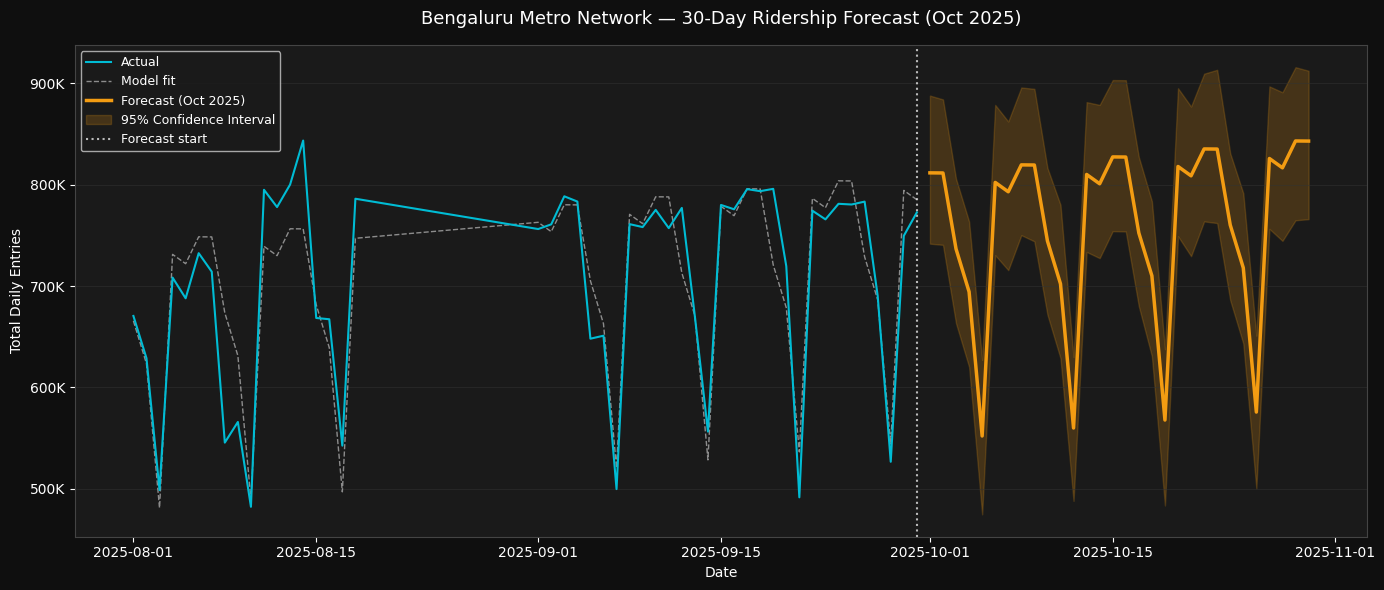

Saved: reports/08_network_forecast.png


In [7]:
fig, ax = plt.subplots(figsize=(14, 6))

# Plot actual data
ax.plot(network_daily['ds'], network_daily['y'],
     color='#00bcd4', linewidth=1.5, label='Actual', zorder=3)

# Plot historical fit
ax.plot(historical_forecast['ds'], historical_forecast['yhat'],
     color='#ffffff', linewidth=1, alpha=0.5, linestyle='--', label='Model fit')

# Plot future forecast
ax.plot(future_forecast['ds'], future_forecast['yhat'],
     color='#f39c12', linewidth=2.5, label='Forecast (Oct 2025)', zorder=4)

# Confidence interval
ax.fill_between(
     future_forecast['ds'],
     future_forecast['yhat_lower'],
     future_forecast['yhat_upper'],
     alpha=0.2, color='#f39c12', label='95% Confidence Interval'
)

# Mark the forecast start
ax.axvline(network_daily['ds'].max(), color='white',
          linestyle=':', alpha=0.7, linewidth=1.5, label='Forecast start')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(
     lambda x, _: f'{x/1000:.0f}K'))
ax.set_title('Bengaluru Metro Network — 30-Day Ridership Forecast (Oct 2025)',
          fontsize=13, pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Total Daily Entries')
ax.legend(fontsize=9)
ax.grid(True, axis='y')

plt.tight_layout()
plt.savefig('../reports/08_network_forecast.png', dpi=150,
          bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved: reports/08_network_forecast.png")

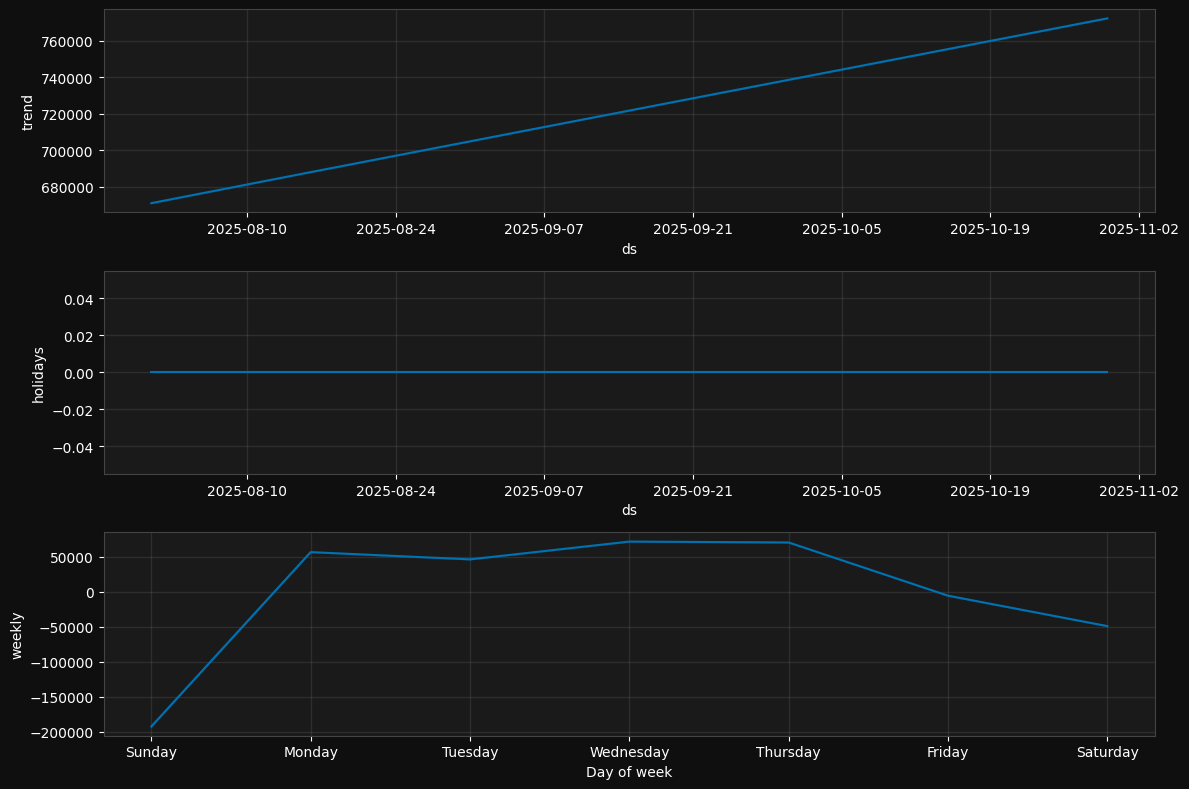

Saved: reports/09_forecast_components.png


In [8]:
# Show trend + weekly seasonality components
fig2 = model.plot_components(forecast)
fig2.set_size_inches(12, 8)
fig2.patch.set_facecolor('#0f0f0f')
for ax in fig2.axes:
     ax.set_facecolor('#1a1a1a')
     ax.tick_params(colors='white')
     ax.yaxis.label.set_color('white')
     ax.xaxis.label.set_color('white')
     ax.title.set_color('white')

plt.tight_layout()
plt.savefig('../reports/09_forecast_components.png', dpi=150,
          bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print("Saved: reports/09_forecast_components.png")

## Step 6: Evaluate Model Accuracy

We use cross-validation to measure forecast accuracy.
We simulate forecasting from different points in our history
and measure how far off the predictions were.

**MAPE** (Mean Absolute Percentage Error) is the key metric.
- Under 10% = good for a business forecasting model
- Under 5% = excellent

In [9]:
from prophet.diagnostics import cross_validation, performance_metrics

# Cross-validate — use 30 days of training, forecast 7 days ahead
# With only 49 days of data this is the maximum we can reasonably do
df_cv = cross_validation(
     model,
     initial='30 days',
     period='7 days',
     horizon='7 days',
     parallel=None
)

df_metrics = performance_metrics(df_cv)

print("=== MODEL PERFORMANCE ===")
print(df_metrics[['horizon', 'mae', 'mape', 'rmse']].round(3).to_string(index=False))
print()
print(f"Average MAPE: {df_metrics['mape'].mean()*100:.1f}%")
print(f"Average MAE:  {df_metrics['mae'].mean():,.0f} entries/day")

  0%|          | 0/4 [00:00<?, ?it/s]07:59:45 - cmdstanpy - INFO - Chain [1] start processing
07:59:45 - cmdstanpy - INFO - Chain [1] done processing
 25%|██▌       | 1/4 [00:00<00:01,  2.05it/s]07:59:45 - cmdstanpy - INFO - Chain [1] start processing
07:59:45 - cmdstanpy - INFO - Chain [1] done processing
 50%|█████     | 2/4 [00:01<00:01,  1.85it/s]07:59:46 - cmdstanpy - INFO - Chain [1] start processing
07:59:46 - cmdstanpy - INFO - Chain [1] done processing
 75%|███████▌  | 3/4 [00:01<00:00,  1.72it/s]07:59:46 - cmdstanpy - INFO - Chain [1] start processing
07:59:47 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 4/4 [00:02<00:00,  1.74it/s]


=== MODEL PERFORMANCE ===
horizon       mae  mape      rmse
 1 days 21526.161 0.027 23332.357
 2 days 32908.426 0.042 35784.906
 3 days 78807.164 0.103 84916.458
 4 days 23130.114 0.034 28852.537
 5 days 44259.849 0.087 48291.999
 6 days 32620.402 0.043 38531.090
 7 days 19431.989 0.025 21306.917

Average MAPE: 5.2%
Average MAE:  36,098 entries/day


## Step 7: Top 5 Station Forecasts

Beyond network-level, we forecast the top 5 stations individually.
This gives operations teams station-specific demand planning data.

07:59:53 - cmdstanpy - INFO - Chain [1] start processing


Top 5 stations: ['Kempegowda', 'Benniganahalli', 'Indiranagar', 'MG Road', 'Krishnarajapura']


07:59:53 - cmdstanpy - INFO - Chain [1] done processing
07:59:53 - cmdstanpy - INFO - Chain [1] start processing
07:59:54 - cmdstanpy - INFO - Chain [1] done processing
07:59:54 - cmdstanpy - INFO - Chain [1] start processing
07:59:54 - cmdstanpy - INFO - Chain [1] done processing
07:59:55 - cmdstanpy - INFO - Chain [1] start processing
07:59:55 - cmdstanpy - INFO - Chain [1] done processing
07:59:55 - cmdstanpy - INFO - Chain [1] start processing
07:59:55 - cmdstanpy - INFO - Chain [1] done processing


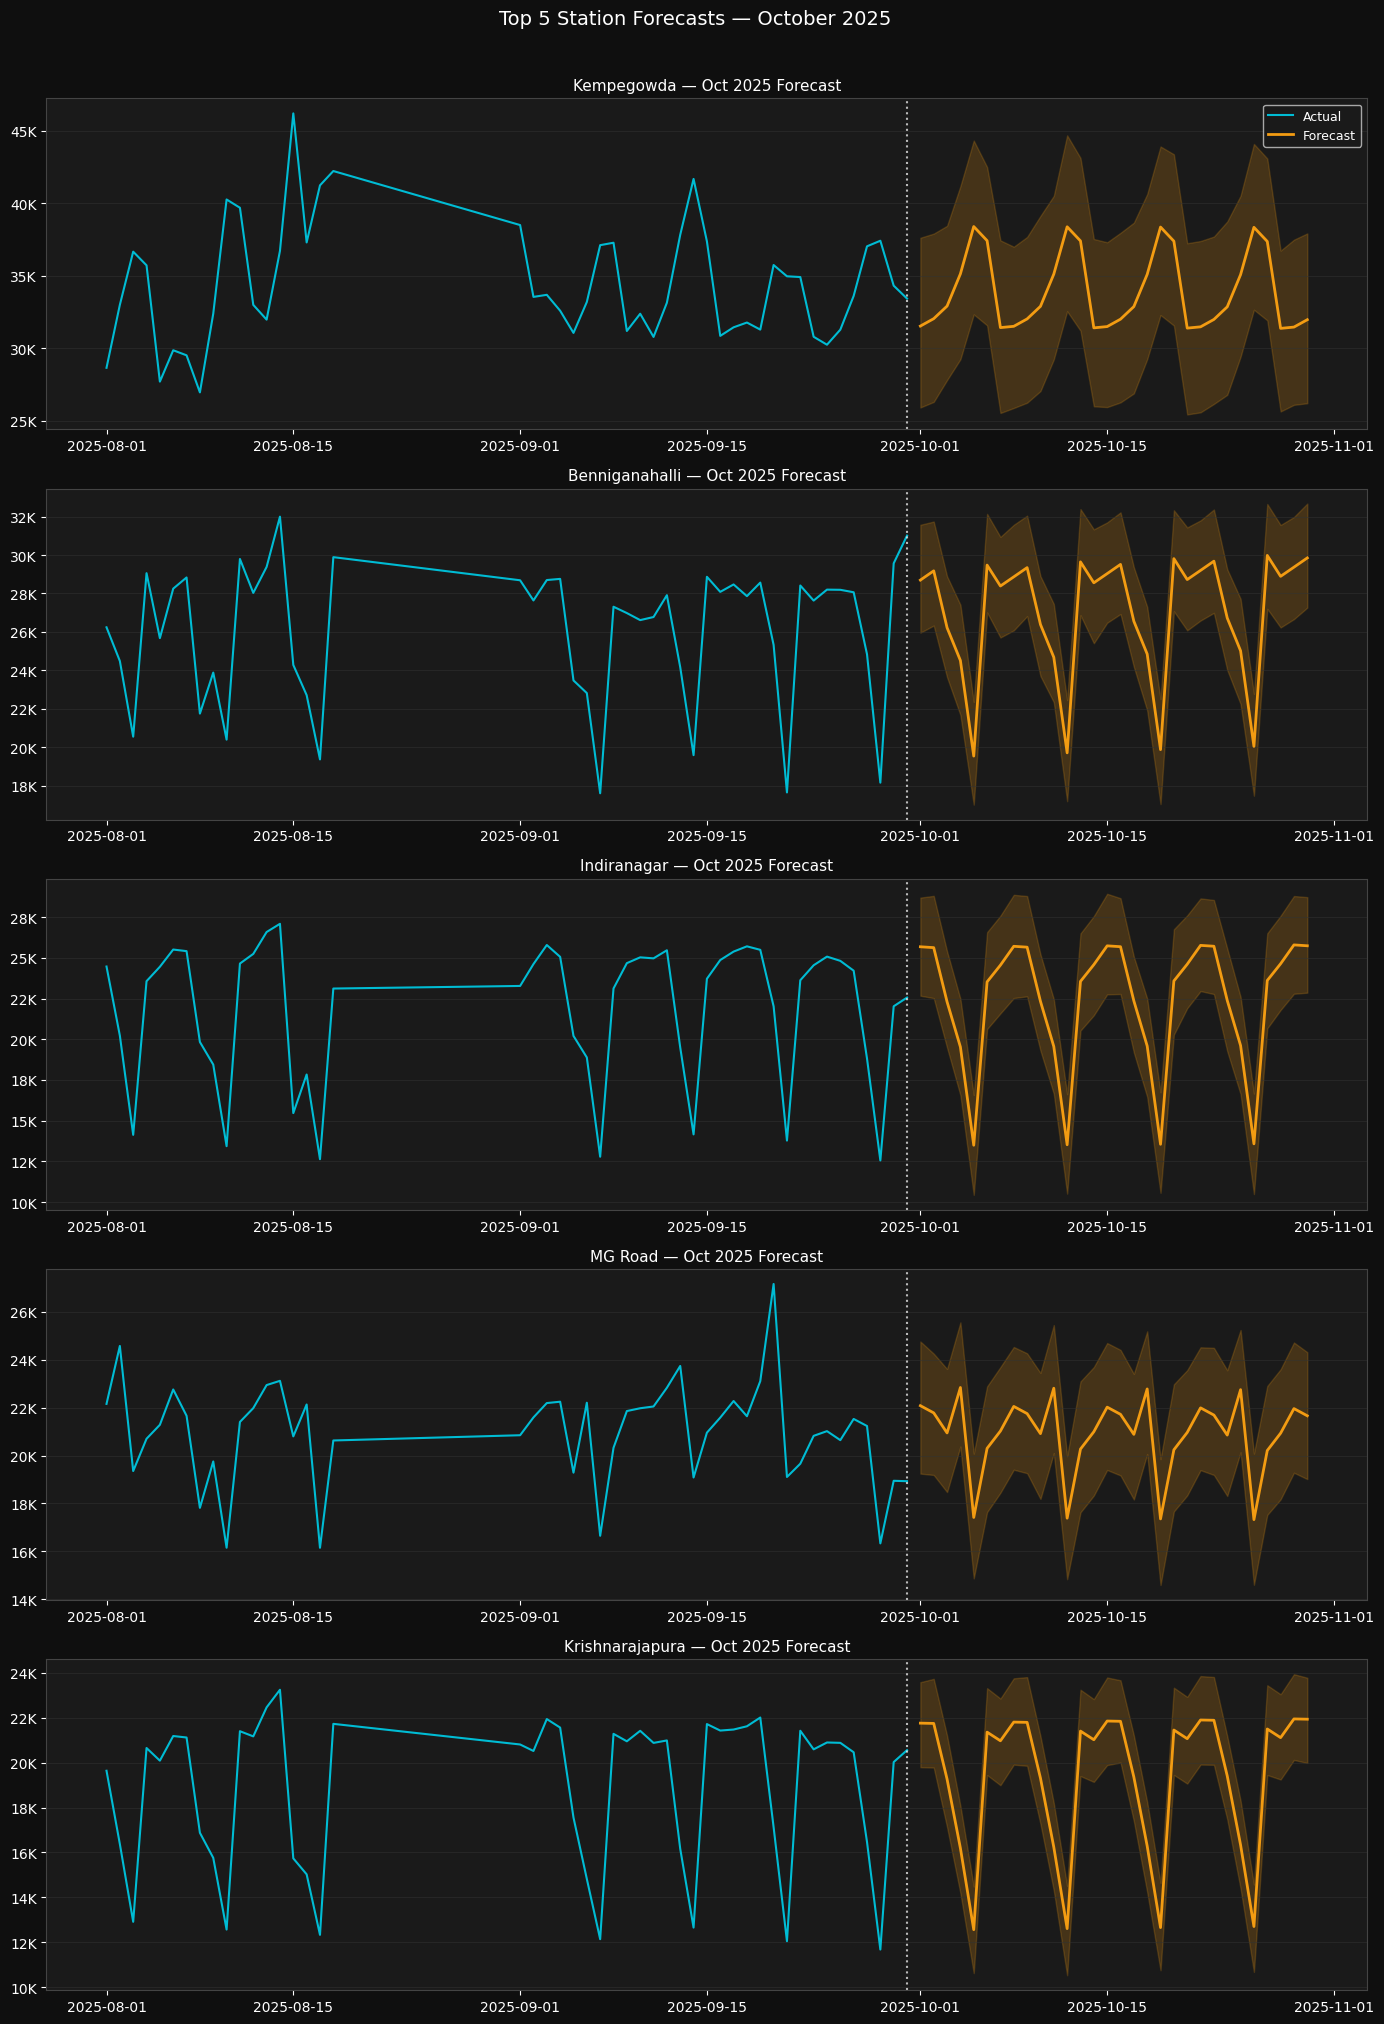

Saved: reports/10_station_forecasts.png


In [10]:
# Get top 5 stations by total entries
top5_stations = (
     df[df['transaction_type'] == 'Entry']
     .groupby('station_name')['daily_count']
     .sum()
     .nlargest(5)
     .index.tolist()
)
print("Top 5 stations:", top5_stations)

fig, axes = plt.subplots(5, 1, figsize=(14, 20))

station_forecasts = {}

for i, station in enumerate(top5_stations):
     # Prepare station time series
     station_ts = (
          df[(df['transaction_type'] == 'Entry') & 
               (df['station_name'] == station)]
          .groupby('date')['daily_count']
          .sum()
          .reset_index()
          .rename(columns={'date': 'ds', 'daily_count': 'y'})
     )
     station_ts['ds'] = pd.to_datetime(station_ts['ds'])
     station_ts = station_ts.sort_values('ds')

     # Train model
     m = Prophet(
          changepoint_prior_scale=0.05,
          holidays=prophet_holidays,
          weekly_seasonality=True,
          yearly_seasonality=False,
          interval_width=0.95
     )
     m.fit(station_ts)

     # Forecast
     future_s = m.make_future_dataframe(periods=30)
     forecast_s = m.predict(future_s)
     future_s_only = forecast_s[forecast_s['ds'] > station_ts['ds'].max()]
     station_forecasts[station] = future_s_only

     # Plot
     ax = axes[i]
     ax.plot(station_ts['ds'], station_ts['y'],
               color='#00bcd4', linewidth=1.5, label='Actual')
     ax.plot(future_s_only['ds'], future_s_only['yhat'],
               color='#f39c12', linewidth=2, label='Forecast')
     ax.fill_between(future_s_only['ds'],
                         future_s_only['yhat_lower'],
                         future_s_only['yhat_upper'],
                         alpha=0.2, color='#f39c12')
     ax.axvline(station_ts['ds'].max(), color='white',
                    linestyle=':', alpha=0.7)
     ax.set_title(f'{station} — Oct 2025 Forecast',
                    fontsize=11, color='white')
     ax.yaxis.set_major_formatter(
          mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
     ax.set_facecolor('#1a1a1a')
     ax.tick_params(colors='white')
     ax.grid(True, axis='y', color='#333333', alpha=0.5)
     if i == 0:
          ax.legend(fontsize=9)

plt.suptitle('Top 5 Station Forecasts — October 2025',
          fontsize=14, color='white', y=1.01)
fig.patch.set_facecolor('#0f0f0f')
plt.tight_layout()
plt.savefig('../reports/10_station_forecasts.png', dpi=150,
          bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print("Saved: reports/10_station_forecasts.png")

In [11]:
print("=" * 55)
print("FORECASTING SUMMARY — OCT 2025")
print("=" * 55)

avg_forecast = future_forecast['yhat'].mean()
avg_actual   = network_daily['y'].mean()
growth_pct   = (avg_forecast - avg_actual) / avg_actual * 100

print(f"\nNetwork forecast (Oct 2025 avg/day): {avg_forecast:,.0f}")
print(f"Historical avg (Aug-Sep 2025):       {avg_actual:,.0f}")
print(f"Projected change:                    {growth_pct:+.1f}%")
print(f"\nTop station Oct forecast (avg/day):")
for station, fc in station_forecasts.items():
     print(f"  {station:<35} {fc['yhat'].mean():>8,.0f}")
print()
print(f"Model MAPE: {df_metrics['mape'].mean()*100:.1f}%")
print("=" * 55)

FORECASTING SUMMARY — OCT 2025

Network forecast (Oct 2025 avg/day): 760,852
Historical avg (Aug-Sep 2025):       704,956
Projected change:                    +7.9%

Top station Oct forecast (avg/day):
  Kempegowda                            33,938
  Benniganahalli                        27,013
  Indiranagar                           22,388
  MG Road                               20,930
  Krishnarajapura                       19,379

Model MAPE: 5.2%
